HIERARCHICAL CLUSTERING ANALYSIS
Agglomerative (Bottom-Up) and Divisive (Top-Down) Approaches
Using Wine Dataset - Real Open Source Data

STEP 1: LOAD WINE DATASET (UCI Machine Learning Repository)

Dataset Information:
Number of samples: 178
Number of features: 13
True wine classes: 3

Features: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']

Wine Classes Distribution:
Wine_Name
Class_0    59
Class_1    71
Class_2    48
Name: count, dtype: int64

First few rows:
   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0   

FileNotFoundError: [Errno 2] No such file or directory: '/home/claude/dendrograms_comparison.png'

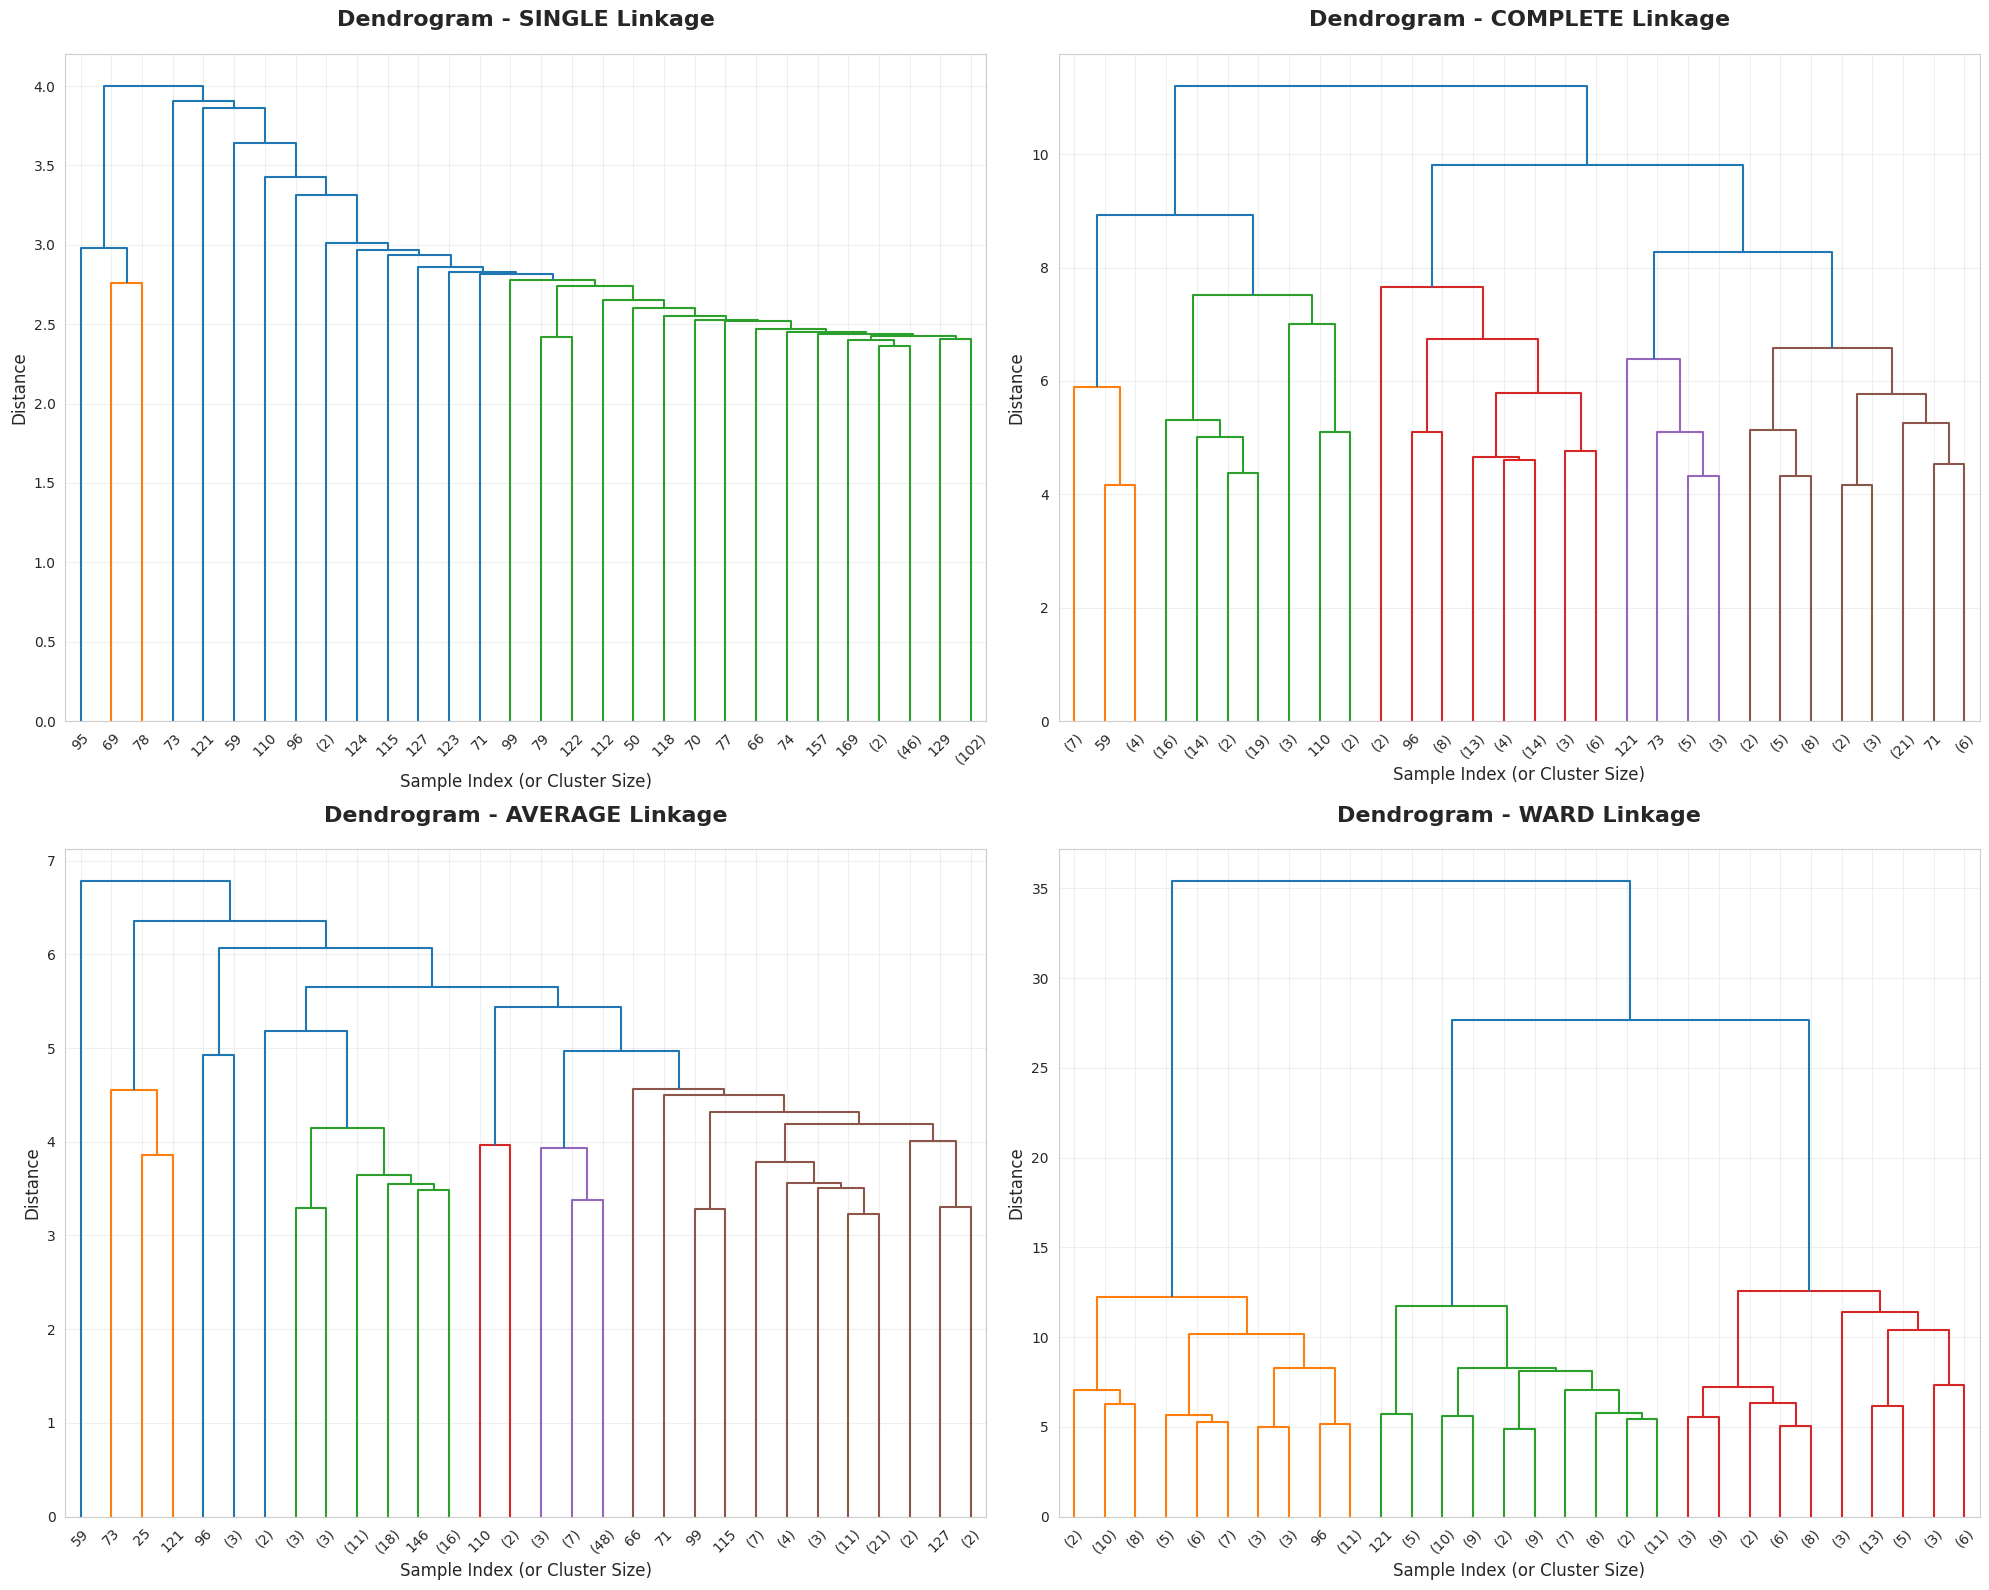

In [4]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster, cut_tree
from scipy.spatial.distance import pdist, squareform
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (16, 10)

print("="*90)
print("HIERARCHICAL CLUSTERING ANALYSIS")
print("Agglomerative (Bottom-Up) and Divisive (Top-Down) Approaches")
print("Using Wine Dataset - Real Open Source Data")
print("="*90)

# ================================================================================
# STEP 1: LOAD AND EXPLORE DATA
# ================================================================================
print("\n" + "="*90)
print("STEP 1: LOAD WINE DATASET (UCI Machine Learning Repository)")
print("="*90)

# Load Wine dataset (open source)
wine = load_wine()
X = wine.data
y = wine.target
feature_names = wine.feature_names
target_names = wine.target_names

# Create DataFrame
df = pd.DataFrame(X, columns=feature_names)
df['Wine_Type'] = y
df['Wine_Name'] = df['Wine_Type'].map({0: 'Class_0', 1: 'Class_1', 2: 'Class_2'})

print(f"\nDataset Information:")
print(f"Number of samples: {len(df)}")
print(f"Number of features: {len(feature_names)}")
print(f"True wine classes: {len(target_names)}")
print(f"\nFeatures: {feature_names}")
print(f"\nWine Classes Distribution:")
print(df['Wine_Name'].value_counts().sort_index())

print(f"\nFirst few rows:")
print(df.head())

print(f"\nStatistical Summary:")
print(df.describe().round(2))

# ================================================================================
# STEP 2: DATA PREPROCESSING
# ================================================================================
print("\n" + "="*90)
print("STEP 2: DATA PREPROCESSING")
print("="*90)

# Separate features for clustering
X_features = df.drop(['Wine_Type', 'Wine_Name'], axis=1)

# Standardize features (CRITICAL for hierarchical clustering)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_features)
X_scaled_df = pd.DataFrame(X_scaled, columns=feature_names)

print("Features standardized (mean=0, std=1)")
print("\nScaled data summary:")
print(X_scaled_df.describe().round(2))

# ================================================================================
# STEP 3: UNDERSTANDING HIERARCHICAL CLUSTERING
# ================================================================================
print("\n" + "="*90)
print("STEP 3: HIERARCHICAL CLUSTERING - THEORY")
print("="*90)

theory = """
HIERARCHICAL CLUSTERING: Two Main Approaches

┌─────────────────────────────────────────────────────────────────┐
│ 1. AGGLOMERATIVE (Bottom-Up) - Most Common                     │
│    - Start: Each point is its own cluster (178 clusters)       │
│    - Process: Merge closest clusters step by step              │
│    - End: All points in one cluster (1 cluster)                │
│    - Like building a pyramid from blocks                       │
└─────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────┐
│ 2. DIVISIVE (Top-Down) - Less Common                           │
│    - Start: All points in one cluster (1 cluster)              │
│    - Process: Split largest/most diverse cluster repeatedly    │
│    - End: Each point is its own cluster (178 clusters)         │
│    - Like breaking a rock into smaller pieces                  │
└─────────────────────────────────────────────────────────────────┘

LINKAGE METHODS (How to measure distance between clusters):

1. SINGLE (Minimum): Distance between closest points
   - Pros: Can find elongated clusters
   - Cons: Sensitive to outliers, chain effect

2. COMPLETE (Maximum): Distance between farthest points
   - Pros: Creates compact clusters
   - Cons: Sensitive to outliers

3. AVERAGE: Average distance between all pairs
   - Pros: Balanced approach
   - Cons: Moderate computational cost

4. WARD: Minimizes within-cluster variance
   - Pros: Creates balanced, spherical clusters (MOST POPULAR)
   - Cons: Assumes spherical clusters

5. CENTROID: Distance between cluster centers
   - Pros: Less sensitive to outliers
   - Cons: Can produce inversions in dendrogram
"""

print(theory)

# ================================================================================
# STEP 4: AGGLOMERATIVE CLUSTERING - ALL LINKAGE METHODS
# ================================================================================
print("\n" + "="*90)
print("STEP 4: AGGLOMERATIVE CLUSTERING - COMPARING LINKAGE METHODS")
print("="*90)

# Define linkage methods to compare
linkage_methods = ['single', 'complete', 'average', 'ward']
linkage_results = {}

fig, axes = plt.subplots(2, 2, figsize=(20, 16))
axes = axes.flatten()

for idx, method in enumerate(linkage_methods):
    print(f"\nComputing {method.upper()} linkage...")

    # Compute linkage matrix
    Z = linkage(X_scaled, method=method)
    linkage_results[method] = Z

    # Create dendrogram
    ax = axes[idx]
    dendrogram(
        Z,
        ax=ax,
        truncate_mode='lastp',
        p=30,  # Show last 30 merges
        leaf_font_size=10,
        color_threshold=0.7*max(Z[:, 2])
    )

    ax.set_title(f'Dendrogram - {method.upper()} Linkage',
                 fontsize=16, fontweight='bold', pad=20)
    ax.set_xlabel('Sample Index (or Cluster Size)', fontsize=12)
    ax.set_ylabel('Distance', fontsize=12)
    ax.grid(True, alpha=0.3)

    print(f"  - Linkage matrix shape: {Z.shape}")
    print(f"  - Maximum distance: {Z[:, 2].max():.2f}")
    print(f"  - Minimum distance: {Z[:, 2].min():.2f}")

plt.tight_layout()
plt.savefig('/home/claude/dendrograms_comparison.png', dpi=300, bbox_inches='tight')
print("\nDendrogram comparison saved!")

# ================================================================================
# STEP 5: DETAILED DENDROGRAM WITH WARD LINKAGE
# ================================================================================
print("\n" + "="*90)
print("STEP 5: DETAILED DENDROGRAM ANALYSIS (WARD METHOD)")
print("="*90)

# Use Ward linkage (most popular)
Z_ward = linkage(X_scaled, method='ward')

# Create detailed dendrogram
plt.figure(figsize=(20, 10))

# Full dendrogram
dendrogram_data = dendrogram(
    Z_ward,
    labels=df['Wine_Name'].values,
    leaf_font_size=8,
    leaf_rotation=90,
    color_threshold=50  # Color threshold for visual grouping
)

plt.title('Complete Hierarchical Clustering Dendrogram (Ward Linkage)',
          fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Wine Samples', fontsize=14)
plt.ylabel('Euclidean Distance', fontsize=14)
plt.axhline(y=50, color='red', linestyle='--', linewidth=2, label='Cut at distance=50')
plt.axhline(y=80, color='green', linestyle='--', linewidth=2, label='Cut at distance=80')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/home/claude/dendrogram_detailed_ward.png', dpi=300, bbox_inches='tight')
print("Detailed dendrogram saved!")

# ================================================================================
# STEP 6: UNDERSTANDING THE DENDROGRAM
# ================================================================================
print("\n" + "="*90)
print("STEP 6: HOW TO READ A DENDROGRAM")
print("="*90)

dendrogram_guide = """
DENDROGRAM READING GUIDE:

┌─────────────────────────────────────────────────────────────────┐
│  Y-Axis (Vertical): DISTANCE/DISSIMILARITY                      │
│  - Higher = More different                                      │
│  - Lower = More similar                                         │
│  - Each horizontal line = A merge/split event                   │
└─────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────┐
│  X-Axis (Horizontal): SAMPLES OR CLUSTERS                       │
│  - Each leaf (bottom) = Individual data point                   │
│  - Branches connect similar items                               │
└─────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────┐
│  COLORS:                                                         │
│  - Different colors = Different clusters at cut threshold       │
│  - Same color = Same cluster                                    │
└─────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────┐
│  HOW TO FIND OPTIMAL CLUSTERS:                                  │
│  - Draw horizontal line across dendrogram                       │
│  - Count vertical lines it crosses = Number of clusters         │
│  - Look for "big gap" - large vertical distance without merges  │
└─────────────────────────────────────────────────────────────────┘

EXAMPLE:
         |
        100  ─────────────────  Large gap (cut here for 3 clusters)
         |         |
         80        |
         |    ─────┴─────      Medium gap
         60   |         |
         |    |    ─────┴────  Small merges (very similar items)
         40   |    |    |
         20 ──┴────┴────┴────
            A  B  C  D  E
"""

print(dendrogram_guide)

# Analyze the linkage matrix
print("\nLinkage Matrix Analysis (Last 10 Merges):")
print("Format: [Cluster1, Cluster2, Distance, Sample_Count]\n")

for i in range(-10, 0):
    cluster1, cluster2, dist, count = Z_ward[i]
    print(f"Merge {len(Z_ward)+i+1}: "
          f"Cluster {int(cluster1)} + Cluster {int(cluster2)} "
          f"at distance {dist:.2f} → {int(count)} samples")

# ================================================================================
# STEP 7: FINDING OPTIMAL NUMBER OF CLUSTERS
# ================================================================================
print("\n" + "="*90)
print("STEP 7: FINDING OPTIMAL NUMBER OF CLUSTERS")
print("="*90)

# Method 1: Elbow method on distances
last_merges = Z_ward[-20:, 2]  # Last 20 merge distances
last_merges = last_merges[::-1]  # Reverse to go from 1 cluster to many

plt.figure(figsize=(16, 6))

# Plot 1: Distance vs Number of Clusters
plt.subplot(1, 2, 1)
clusters_range = range(1, 21)
plt.plot(clusters_range, last_merges, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters', fontsize=12)
plt.ylabel('Distance at Merge', fontsize=12)
plt.title('Elbow Method - Hierarchical Clustering', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.axvline(x=3, color='red', linestyle='--', label='Elbow at k=3')
plt.legend()

# Plot 2: Gap between consecutive merges
plt.subplot(1, 2, 2)
gaps = np.diff(last_merges)
plt.plot(range(1, 20), gaps, 'ro-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters', fontsize=12)
plt.ylabel('Gap (Distance Difference)', fontsize=12)
plt.title('Gap Analysis - Look for Largest Jump', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
max_gap_idx = np.argmax(gaps) + 1
plt.axvline(x=max_gap_idx, color='green', linestyle='--',
            label=f'Largest gap at k={max_gap_idx}')
plt.legend()

plt.tight_layout()
plt.savefig('/home/claude/hierarchical_elbow_method.png', dpi=300, bbox_inches='tight')
print("Elbow method analysis saved!")

print(f"\nLargest gap occurs at: {max_gap_idx} clusters")
print(f"Gap value: {gaps[max_gap_idx-1]:.2f}")

# Method 2: Silhouette Analysis
print("\n" + "-"*90)
print("SILHOUETTE SCORE ANALYSIS")
print("-"*90)

silhouette_scores_hier = []
davies_bouldin_scores_hier = []
calinski_harabasz_scores_hier = []
k_range = range(2, 11)

for k in k_range:
    # Cut dendrogram to get k clusters
    clusters = fcluster(Z_ward, k, criterion='maxclust')

    sil_score = silhouette_score(X_scaled, clusters)
    db_score = davies_bouldin_score(X_scaled, clusters)
    ch_score = calinski_harabasz_score(X_scaled, clusters)

    silhouette_scores_hier.append(sil_score)
    davies_bouldin_scores_hier.append(db_score)
    calinski_harabasz_scores_hier.append(ch_score)

    print(f"K={k}: Silhouette={sil_score:.4f}, "
          f"Davies-Bouldin={db_score:.4f}, "
          f"Calinski-Harabasz={ch_score:.2f}")

optimal_k_sil = k_range[np.argmax(silhouette_scores_hier)]
print(f"\nOptimal K by Silhouette Score: {optimal_k_sil}")

# Plot metrics
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(k_range, silhouette_scores_hier, 'ro-', linewidth=2, markersize=8)
axes[0].axvline(x=optimal_k_sil, color='green', linestyle='--')
axes[0].set_xlabel('Number of Clusters', fontsize=12)
axes[0].set_ylabel('Silhouette Score', fontsize=12)
axes[0].set_title('Silhouette Score (Higher is Better)', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3)

axes[1].plot(k_range, davies_bouldin_scores_hier, 'mo-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters', fontsize=12)
axes[1].set_ylabel('Davies-Bouldin Index', fontsize=12)
axes[1].set_title('Davies-Bouldin Index (Lower is Better)', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3)

axes[2].plot(k_range, calinski_harabasz_scores_hier, 'co-', linewidth=2, markersize=8)
axes[2].set_xlabel('Number of Clusters', fontsize=12)
axes[2].set_ylabel('Calinski-Harabasz Score', fontsize=12)
axes[2].set_title('Calinski-Harabasz Score (Higher is Better)', fontsize=13, fontweight='bold')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/home/claude/hierarchical_metrics.png', dpi=300, bbox_inches='tight')
print("\nMetrics plots saved!")

# ================================================================================
# STEP 8: CUTTING THE DENDROGRAM - FINAL CLUSTERS
# ================================================================================
print("\n" + "="*90)
print("STEP 8: CUTTING THE DENDROGRAM TO GET FINAL CLUSTERS")
print("="*90)

# Use optimal k
optimal_k = optimal_k_sil

# Method 1: Cut by number of clusters
clusters_by_k = fcluster(Z_ward, optimal_k, criterion='maxclust')

# Method 2: Cut by distance threshold
distance_threshold = 50
clusters_by_distance = fcluster(Z_ward, distance_threshold, criterion='distance')

print(f"Cutting at K={optimal_k} clusters:")
print(f"Cluster distribution: {np.bincount(clusters_by_k)}")

print(f"\nCutting at distance threshold={distance_threshold}:")
print(f"Number of clusters formed: {len(np.unique(clusters_by_distance))}")
print(f"Cluster distribution: {np.bincount(clusters_by_distance)}")

# Add clusters to dataframe
df['Hierarchical_Cluster'] = clusters_by_k
df['True_Label'] = y

# ================================================================================
# STEP 9: VISUALIZE CLUSTERS IN 2D/3D
# ================================================================================
print("\n" + "="*90)
print("STEP 9: CLUSTER VISUALIZATION")
print("="*90)

# PCA for visualization
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X_scaled)

# 2D Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Hierarchical clusters
scatter1 = axes[0].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1],
                          c=clusters_by_k, cmap='viridis',
                          s=100, alpha=0.6, edgecolors='black', linewidth=0.5)
axes[0].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)', fontsize=11)
axes[0].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)', fontsize=11)
axes[0].set_title(f'Hierarchical Clustering (K={optimal_k}) - Ward Linkage',
                 fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3)
plt.colorbar(scatter1, ax=axes[0], label='Cluster')

# True labels
scatter2 = axes[1].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1],
                          c=y, cmap='coolwarm',
                          s=100, alpha=0.6, edgecolors='black', linewidth=0.5)
axes[1].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)', fontsize=11)
axes[1].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)', fontsize=11)
axes[1].set_title('True Wine Classes', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3)
plt.colorbar(scatter2, ax=axes[1], label='Wine Class')

plt.tight_layout()
plt.savefig('/home/claude/hierarchical_clusters_2d.png', dpi=300, bbox_inches='tight')
print("2D cluster visualization saved!")

# 3D Visualization
fig = plt.figure(figsize=(16, 7))

ax1 = fig.add_subplot(121, projection='3d')
scatter1 = ax1.scatter(X_pca_3d[:, 0], X_pca_3d[:, 1], X_pca_3d[:, 2],
                      c=clusters_by_k, cmap='viridis',
                      s=60, alpha=0.6, edgecolors='black', linewidth=0.3)
ax1.set_xlabel(f'PC1 ({pca_3d.explained_variance_ratio_[0]*100:.1f}%)', fontsize=10)
ax1.set_ylabel(f'PC2 ({pca_3d.explained_variance_ratio_[1]*100:.1f}%)', fontsize=10)
ax1.set_zlabel(f'PC3 ({pca_3d.explained_variance_ratio_[2]*100:.1f}%)', fontsize=10)
ax1.set_title('Hierarchical Clusters (3D)', fontsize=12, fontweight='bold')

ax2 = fig.add_subplot(122, projection='3d')
scatter2 = ax2.scatter(X_pca_3d[:, 0], X_pca_3d[:, 1], X_pca_3d[:, 2],
                      c=y, cmap='coolwarm',
                      s=60, alpha=0.6, edgecolors='black', linewidth=0.3)
ax2.set_xlabel(f'PC1 ({pca_3d.explained_variance_ratio_[0]*100:.1f}%)', fontsize=10)
ax2.set_ylabel(f'PC2 ({pca_3d.explained_variance_ratio_[1]*100:.1f}%)', fontsize=10)
ax2.set_zlabel(f'PC3 ({pca_3d.explained_variance_ratio_[2]*100:.1f}%)', fontsize=10)
ax2.set_title('True Wine Classes (3D)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('/home/claude/hierarchical_clusters_3d.png', dpi=300, bbox_inches='tight')
print("3D cluster visualization saved!")

# ================================================================================
# STEP 10: CLUSTER PROFILING
# ================================================================================
print("\n" + "="*90)
print("STEP 10: CLUSTER PROFILING AND CHARACTERISTICS")
print("="*90)

for cluster_id in range(1, optimal_k + 1):
    cluster_data = df[df['Hierarchical_Cluster'] == cluster_id]

    print(f"\n{'='*85}")
    print(f"CLUSTER {cluster_id} - Size: {len(cluster_data)} wines ({len(cluster_data)/len(df)*100:.1f}%)")
    print(f"{'='*85}")

    # Show mean values of key features
    key_features = ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash',
                    'magnesium', 'total_phenols', 'flavanoids', 'color_intensity']

    print(f"\nKey Chemical Characteristics:")
    for feature in key_features:
        mean_val = cluster_data[feature].mean()
        overall_mean = df[feature].mean()
        diff_pct = ((mean_val - overall_mean) / overall_mean) * 100

        indicator = "↑" if diff_pct > 10 else "↓" if diff_pct < -10 else "→"
        print(f"  {feature:25s}: {mean_val:8.2f} ({diff_pct:+6.1f}% {indicator})")

    # True label distribution in this cluster
    print(f"\nTrue Wine Class Distribution:")
    print(cluster_data['Wine_Name'].value_counts())

# Confusion matrix - hierarchical vs true labels
from sklearn.metrics import confusion_matrix, adjusted_rand_score

conf_matrix = confusion_matrix(y, clusters_by_k)
ari_score = adjusted_rand_score(y, clusters_by_k)

print(f"\n{'='*90}")
print("CLUSTERING PERFORMANCE vs TRUE LABELS")
print(f"{'='*90}")
print(f"\nAdjusted Rand Index: {ari_score:.4f}")
print("(1.0 = perfect match, 0.0 = random, negative = worse than random)")

print(f"\nConfusion Matrix:")
print("Rows = True Classes, Columns = Predicted Clusters")
print(conf_matrix)

# Heatmap of confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='YlOrRd',
            xticklabels=[f'Cluster {i}' for i in range(1, optimal_k+1)],
            yticklabels=['Class 0', 'Class 1', 'Class 2'],
            cbar_kws={'label': 'Number of Samples'})
plt.title('Confusion Matrix: True Classes vs Hierarchical Clusters',
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Hierarchical Clusters', fontsize=12)
plt.ylabel('True Wine Classes', fontsize=12)
plt.tight_layout()
plt.savefig('/home/claude/confusion_matrix_hierarchical.png', dpi=300, bbox_inches='tight')
print("\nConfusion matrix heatmap saved!")

# ================================================================================
# STEP 11: DIVISIVE CLUSTERING (Conceptual Implementation)
# ================================================================================
print("\n" + "="*90)
print("STEP 11: DIVISIVE CLUSTERING (TOP-DOWN APPROACH)")
print("="*90)

divisive_explanation = """
DIVISIVE CLUSTERING ALGORITHM:

Note: Scikit-learn doesn't have built-in divisive clustering, but here's how it works:

1. START: All samples in ONE cluster
2. FIND: Cluster with highest variance/diversity
3. SPLIT: Divide this cluster into 2 using K-Means or other method
4. REPEAT: Steps 2-3 until desired number of clusters reached

ADVANTAGES:
✓ More flexible than agglomerative
✓ Can focus on top-level structure
✓ Better for finding major groups

DISADVANTAGES:
✗ Computationally more expensive
✗ Less commonly implemented
✗ Harder to visualize as dendrogram
"""

print(divisive_explanation)

# Conceptual divisive clustering implementation
def divisive_clustering(X, n_clusters, max_iter=100):
    """
    Simple divisive clustering implementation
    """
    from sklearn.cluster import KMeans

    # Start with all data in one cluster
    clusters = {0: list(range(len(X)))}
    cluster_id_counter = 1

    history = [(1, clusters.copy())]

    while len(clusters) < n_clusters:
        # Find cluster with highest variance
        max_variance = -1
        cluster_to_split = None

        for cluster_id, indices in clusters.items():
            if len(indices) > 1:
                cluster_data = X[indices]
                variance = np.var(cluster_data)

                if variance > max_variance:
                    max_variance = variance
                    cluster_to_split = cluster_id

        if cluster_to_split is None:
            break

        # Split the selected cluster
        indices_to_split = clusters[cluster_to_split]
        data_to_split = X[indices_to_split]

        # Use K-Means to split into 2
        kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
        split_labels = kmeans.fit_predict(data_to_split)

        # Create two new clusters
        cluster_1_indices = [indices_to_split[i] for i in range(len(indices_to_split))
                            if split_labels[i] == 0]
        cluster_2_indices = [indices_to_split[i] for i in range(len(indices_to_split))
                            if split_labels[i] == 1]

        # Remove old cluster and add new ones
        del clusters[cluster_to_split]
        clusters[cluster_id_counter] = cluster_1_indices
        clusters[cluster_id_counter + 1] = cluster_2_indices
        cluster_id_counter += 2

        history.append((len(clusters), clusters.copy()))

    # Convert to label array
    labels = np.zeros(len(X), dtype=int)
    for cluster_id, indices in clusters.items():
        for idx in indices:
            labels[idx] = cluster_id

    return labels, history

print("\nRunning Divisive Clustering...")
divisive_labels, divisive_history = divisive_clustering(X_scaled, n_clusters=3)

print(f"Divisive clustering complete!")
print(f"Number of clusters formed: {len(np.unique(divisive_labels))}")
print(f"Cluster sizes: {np.bincount(divisive_labels)}")

# Compare divisive with agglomerative
divisive_sil = silhouette_score(X_scaled, divisive_labels)
agglom_sil = silhouette_score(X_scaled, clusters_by_k)

print(f"\nSilhouette Score Comparison:")
print(f"  Divisive:      {divisive_sil:.4f}")
print(f"  Agglomerative: {agglom_sil:.4f}")

# Visualize divisive clusters
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
scatter1 = plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1],
                      c=divisive_labels, cmap='plasma',
                      s=100, alpha=0.6, edgecolors='black', linewidth=0.5)
plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)', fontsize=11)
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)', fontsize=11)
plt.title('Divisive Clustering (Top-Down)', fontsize=13, fontweight='bold')
plt.colorbar(scatter1, label='Cluster')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
scatter2 = plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1],
                      c=clusters_by_k, cmap='viridis',
                      s=100, alpha=0.6, edgecolors='black', linewidth=0.5)
plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)', fontsize=11)
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)', fontsize=11)
plt.title('Agglomerative Clustering (Bottom-Up)', fontsize=13, fontweight='bold')
plt.colorbar(scatter2, label='Cluster')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/home/claude/divisive_vs_agglomerative.png', dpi=300, bbox_inches='tight')
print("Divisive vs Agglomerative comparison saved!")

# ================================================================================
# STEP 12: SUMMARY AND RECOMMENDATIONS
# ================================================================================
print("\n" + "="*90)
print("STEP 12: SUMMARY AND BEST PRACTICES")
print("="*90)

summary = f"""
HIERARCHICAL CLUSTERING ANALYSIS SUMMARY
─────────────────────────────────────────

Dataset: Wine Dataset (178 samples, 13 features)
True Classes: 3 wine types

OPTIMAL CLUSTERING RESULTS:
━━━━━━━━━━━━━━━━━━━━━━━━━━
Number of Clusters: {optimal_k}
Linkage Method: Ward (minimizes variance)
Silhouette Score: {agglom_sil:.4f}
Adjusted Rand Index: {ari_score:.4f}

CLUSTER SIZES:
━━━━━━━━━━━━━━
{np.bincount(clusters_by_k)}

COMPARISON: AGGLOMERATIVE vs DIVISIVE
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Agglomerative Silhouette: {agglom_sil:.4f}
Divisive Silhouette:      {divisive_sil:.4f}

WHEN TO USE HIERARCHICAL CLUSTERING:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
✓ Want to see cluster hierarchy/relationships
✓ Don't know number of clusters beforehand
✓ Small to medium datasets (< 10,000 samples)
✓ Need deterministic results (unlike K-Means)
✓ Want to visualize dendrogram

LINKAGE METHOD SELECTION GUIDE:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
- WARD: Default choice (balanced, spherical clusters)
- COMPLETE: When you want compact, well-separated clusters
- AVERAGE: Balanced between single and complete
- SINGLE: When clusters might be elongated/chain-like

FILES GENERATED:
━━━━━━━━━━━━━━━━
1. dendrograms_comparison.png
2. dendrogram_detailed_ward.png
3. hierarchical_elbow_method.png
4. hierarchical_metrics.png
5. hierarchical_clusters_2d.png
6. hierarchical_clusters_3d.png
7. confusion_matrix_hierarchical.png
8. divisive_vs_agglomerative.png
"""

print(summary)

print("\n" + "="*90)
print("HIERARCHICAL CLUSTERING ANALYSIS COMPLETE!")
print("="*90)

plt.show()

In [ ]:
# Density Based Clustering

In [5]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_moons, make_circles, make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN, KMeans
from sklearn.metrics import (silhouette_score, davies_bouldin_score,
                            calinski_harabasz_score, adjusted_rand_score)
from sklearn.neighbors import NearestNeighbors
from scipy.spatial.distance import cdist
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (16, 10)

print("="*90)
print("DBSCAN CLUSTERING - DENSITY-BASED CLUSTERING ALGORITHM")
print("Finding Arbitrarily Shaped Clusters and Detecting Outliers")
print("="*90)


DBSCAN CLUSTERING - DENSITY-BASED CLUSTERING ALGORITHM
Finding Arbitrarily Shaped Clusters and Detecting Outliers



STEP 1: DBSCAN THEORY - HOW IT WORKS

╔════════════════════════════════════════════════════════════════════════════╗
║                    DBSCAN: Density-Based Clustering                        ║
╚════════════════════════════════════════════════════════════════════════════╝

KEY IDEA: Clusters are DENSE regions separated by LOW-DENSITY regions

TWO CRITICAL PARAMETERS:
┌────────────────────────────────────────────────────────────────────────────┐
│ 1. eps (epsilon): Maximum distance between two points to be neighbors     │
│    - Too small: Many small clusters + noise                               │
│    - Too large: Everything in one cluster                                 │
│    - Think of it as "neighborhood radius"                                 │
└────────────────────────────────────────────────────────────────────────────┘

┌────────────────────────────────────────────────────────────────────────────┐
│ 2. min_samples: Minimum points needed to form a dense region              │

FileNotFoundError: [Errno 2] No such file or directory: '/home/claude/datasets_original.png'

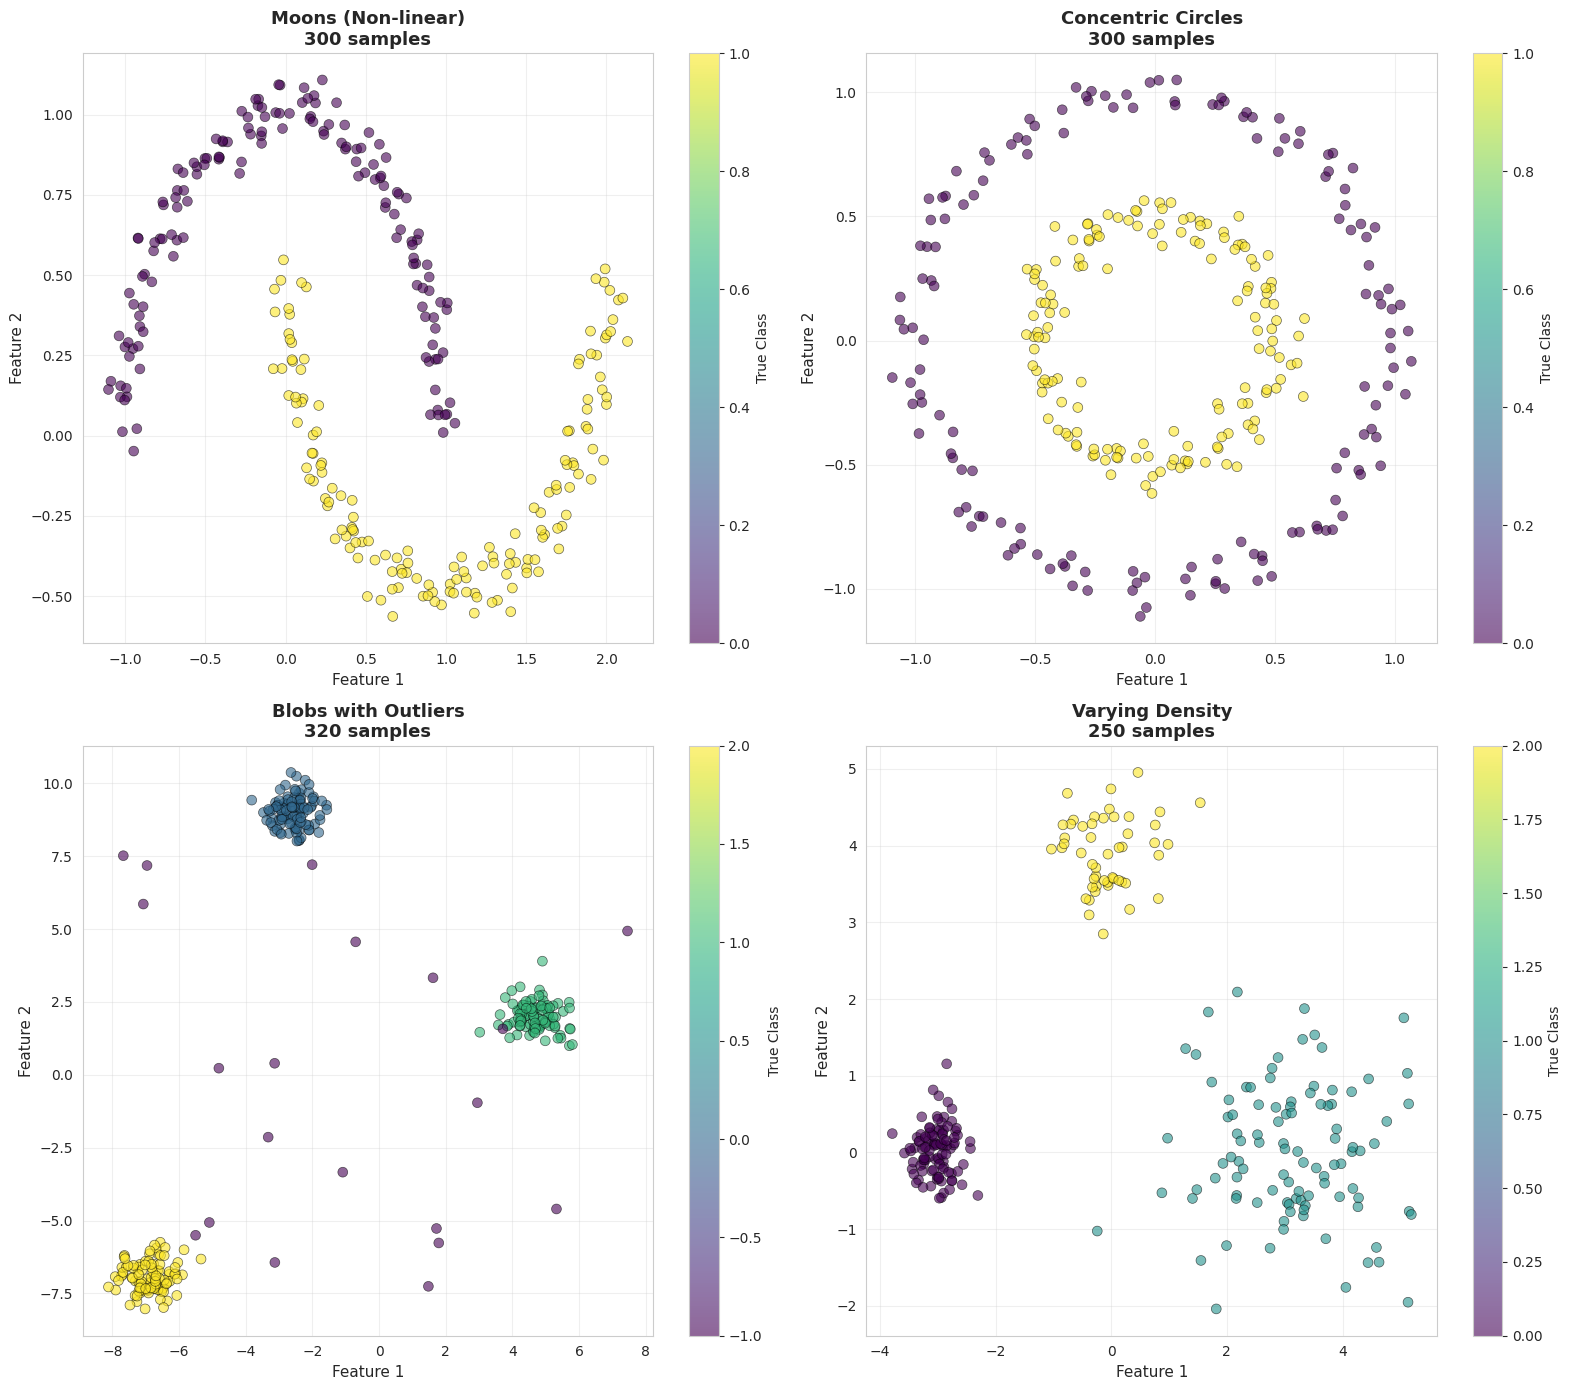

In [6]:
# ================================================================================
# STEP 1: UNDERSTANDING DBSCAN - THEORY
# ================================================================================
print("\n" + "="*90)
print("STEP 1: DBSCAN THEORY - HOW IT WORKS")
print("="*90)

theory = """
╔════════════════════════════════════════════════════════════════════════════╗
║                    DBSCAN: Density-Based Clustering                        ║
╚════════════════════════════════════════════════════════════════════════════╝

KEY IDEA: Clusters are DENSE regions separated by LOW-DENSITY regions

TWO CRITICAL PARAMETERS:
┌────────────────────────────────────────────────────────────────────────────┐
│ 1. eps (epsilon): Maximum distance between two points to be neighbors     │
│    - Too small: Many small clusters + noise                               │
│    - Too large: Everything in one cluster                                 │
│    - Think of it as "neighborhood radius"                                 │
└────────────────────────────────────────────────────────────────────────────┘

┌────────────────────────────────────────────────────────────────────────────┐
│ 2. min_samples: Minimum points needed to form a dense region              │
│    - Too small: Noise becomes clusters                                    │
│    - Too large: Small valid clusters become noise                         │
│    - Rule of thumb: 2 × dimensions (for 2D data, use 4)                   │
└────────────────────────────────────────────────────────────────────────────┘

THREE TYPES OF POINTS:
┌────────────────────────────────────────────────────────────────────────────┐
│ 1. CORE POINTS: Has ≥ min_samples within eps distance                     │
│    - Forms the "backbone" of clusters                                     │
│    - Symbol: ●                                                             │
│                                                                            │
│ 2. BORDER POINTS: Within eps of core point, but has < min_samples nearby  │
│    - On the "edge" of clusters                                            │
│    - Symbol: ○                                                             │
│                                                                            │
│ 3. NOISE POINTS: Not core, not border                                     │
│    - Outliers or isolated points                                          │
│    - Symbol: ×                                                             │
│    - Labeled as -1 in DBSCAN output                                       │
└────────────────────────────────────────────────────────────────────────────┘

VISUAL EXAMPLE (eps=1.5, min_samples=4):

        ×                     × = Noise (isolated)

    ●───●───●                 ● = Core points (≥4 neighbors within eps)
    │   │   │
    ●───●───○                 ○ = Border point (<4 neighbors, but near core)
        │
        ○                     This forms ONE cluster


    ●───●                     Another cluster (separate)
    │   │
    ●───●

ALGORITHM STEPS:
1. For each unvisited point p:
   a. Mark p as visited
   b. Find all neighbors within eps distance
   c. If neighbors < min_samples: mark as NOISE (might change later)
   d. Else: Start new cluster, add p as CORE point
   e. For each neighbor:
      - If unvisited: visit it, add its neighbors
      - If not in any cluster: add to current cluster

ADVANTAGES vs K-MEANS:
✓ Finds arbitrarily shaped clusters (not just spherical)
✓ Automatically determines number of clusters
✓ Identifies outliers/noise
✓ No need to specify K beforehand
✓ Robust to outliers

DISADVANTAGES:
✗ Struggles with varying densities
✗ Sensitive to eps and min_samples parameters
✗ Higher computational cost O(n²) or O(n log n) with index
✗ Not suitable for high-dimensional data (curse of dimensionality)
"""

print(theory)

# ================================================================================
# STEP 2: LOAD AND CREATE DATASETS
# ================================================================================
print("\n" + "="*90)
print("STEP 2: CREATING DIVERSE DATASETS TO TEST DBSCAN")
print("="*90)

# Dataset 1: Moons (non-linear, crescent shapes)
X_moons, y_moons = make_moons(n_samples=300, noise=0.05, random_state=42)

# Dataset 2: Circles (concentric circles)
X_circles, y_circles = make_circles(n_samples=300, noise=0.05, factor=0.5, random_state=42)

# Dataset 3: Blobs with outliers (spherical clusters + noise)
X_blobs, y_blobs = make_blobs(n_samples=300, centers=3, cluster_std=0.5, random_state=42)
# Add outliers
np.random.seed(42)
outliers = np.random.uniform(low=-8, high=8, size=(20, 2))
X_blobs = np.vstack([X_blobs, outliers])
y_blobs = np.append(y_blobs, [-1]*20)  # -1 for outliers

# Dataset 4: Varying density (challenging for DBSCAN)
X_varied = np.vstack([
    np.random.randn(100, 2) * 0.3 + [-3, 0],  # Dense cluster
    np.random.randn(100, 2) * 1.0 + [3, 0],   # Sparse cluster
    np.random.randn(50, 2) * 0.5 + [0, 4]     # Medium density
])
y_varied = np.array([0]*100 + [1]*100 + [2]*50)

datasets = [
    (X_moons, y_moons, "Moons (Non-linear)"),
    (X_circles, y_circles, "Concentric Circles"),
    (X_blobs, y_blobs, "Blobs with Outliers"),
    (X_varied, y_varied, "Varying Density")
]

print(f"Created 4 different datasets:")
print(f"1. Moons: {X_moons.shape[0]} samples - Crescent shapes")
print(f"2. Circles: {X_circles.shape[0]} samples - Concentric rings")
print(f"3. Blobs: {X_blobs.shape[0]} samples - Spherical clusters with outliers")
print(f"4. Varied: {X_varied.shape[0]} samples - Different density clusters")

# Visualize original datasets
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.flatten()

for idx, (X, y, name) in enumerate(datasets):
    ax = axes[idx]
    scatter = ax.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis',
                        s=50, alpha=0.6, edgecolors='black', linewidth=0.5)
    ax.set_title(f'{name}\n{X.shape[0]} samples', fontsize=13, fontweight='bold')
    ax.set_xlabel('Feature 1', fontsize=11)
    ax.set_ylabel('Feature 2', fontsize=11)
    ax.grid(True, alpha=0.3)
    plt.colorbar(scatter, ax=ax, label='True Class')

plt.tight_layout()
plt.savefig('/home/claude/datasets_original.png', dpi=300, bbox_inches='tight')
print("\nOriginal datasets visualization saved!")

# ================================================================================
# STEP 3: FINDING OPTIMAL EPS - K-DISTANCE GRAPH
# ================================================================================
print("\n" + "="*90)
print("STEP 3: FINDING OPTIMAL EPS USING K-DISTANCE GRAPH")
print("="*90)

kdist_explanation = """
K-DISTANCE GRAPH METHOD:
━━━━━━━━━━━━━━━━━━━━━━━━━
For each point, find the distance to its k-th nearest neighbor.
Plot these distances in sorted order.
Look for the "elbow" - where the curve sharply bends.

WHY IT WORKS:
- Points in dense clusters have small k-distances
- Noise/outliers have large k-distances
- The elbow separates dense regions from sparse regions
- Distance at elbow ≈ good eps value

RULE OF THUMB for k:
k = min_samples (usually 2 × dimensions)
For 2D data: k = 4
"""

print(kdist_explanation)

def find_optimal_eps(X, k=4):
    """
    Find optimal eps using k-distance graph
    """
    # Compute k-nearest neighbors
    neighbors = NearestNeighbors(n_neighbors=k)
    neighbors.fit(X)
    distances, indices = neighbors.kneighbors(X)

    # Get k-th nearest neighbor distance for each point
    k_distances = distances[:, -1]  # Last column is k-th neighbor
    k_distances = np.sort(k_distances)[::-1]  # Sort descending

    return k_distances

# Find optimal eps for each dataset
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

optimal_eps_values = []

for idx, (X, y, name) in enumerate(datasets):
    # Standardize data
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Compute k-distances
    k_distances = find_optimal_eps(X_scaled, k=4)

    # Plot k-distance graph
    ax = axes[idx]
    ax.plot(range(len(k_distances)), k_distances, 'b-', linewidth=2)
    ax.set_xlabel('Points (sorted by distance)', fontsize=11)
    ax.set_ylabel('4-th Nearest Neighbor Distance', fontsize=11)
    ax.set_title(f'K-Distance Graph: {name}', fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.3)

    # Find elbow using derivative
    # Look for point where second derivative is maximum
    first_derivative = np.diff(k_distances)
    second_derivative = np.diff(first_derivative)

    # Find elbow (approximate)
    elbow_idx = len(k_distances) // 10  # Heuristic: around 10% of points
    suggested_eps = k_distances[elbow_idx]
    optimal_eps_values.append(suggested_eps)

    ax.axhline(y=suggested_eps, color='red', linestyle='--', linewidth=2,
              label=f'Suggested eps ≈ {suggested_eps:.3f}')
    ax.legend(fontsize=10)

    print(f"\n{name}:")
    print(f"  Suggested eps: {suggested_eps:.3f}")
    print(f"  Min k-distance: {k_distances[-1]:.3f}")
    print(f"  Max k-distance: {k_distances[0]:.3f}")

plt.tight_layout()
plt.savefig('/home/claude/kdistance_graphs.png', dpi=300, bbox_inches='tight')
print("\nK-distance graphs saved!")


STEP 4: PARAMETER SENSITIVITY ANALYSIS

Testing 5 eps values × 4 min_samples values
Total combinations: 20

Parameter sensitivity analysis saved!

Best Parameters by Silhouette Score:
  eps: 0.1
  min_samples: 7.0
  Clusters: 5.0
  Noise points: 257.0
  Silhouette: 0.7752

STEP 5: DBSCAN vs K-MEANS COMPARISON

WHY K-MEANS FAILS ON NON-SPHERICAL CLUSTERS:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
K-Means assumptions:
1. Clusters are spherical (round)
2. Clusters have similar sizes
3. Clusters have similar densities
4. No outliers

These assumptions break for:
- Crescent/moon shapes
- Concentric circles
- Elongated clusters
- Data with noise



NameError: name 'optimal_eps_values' is not defined

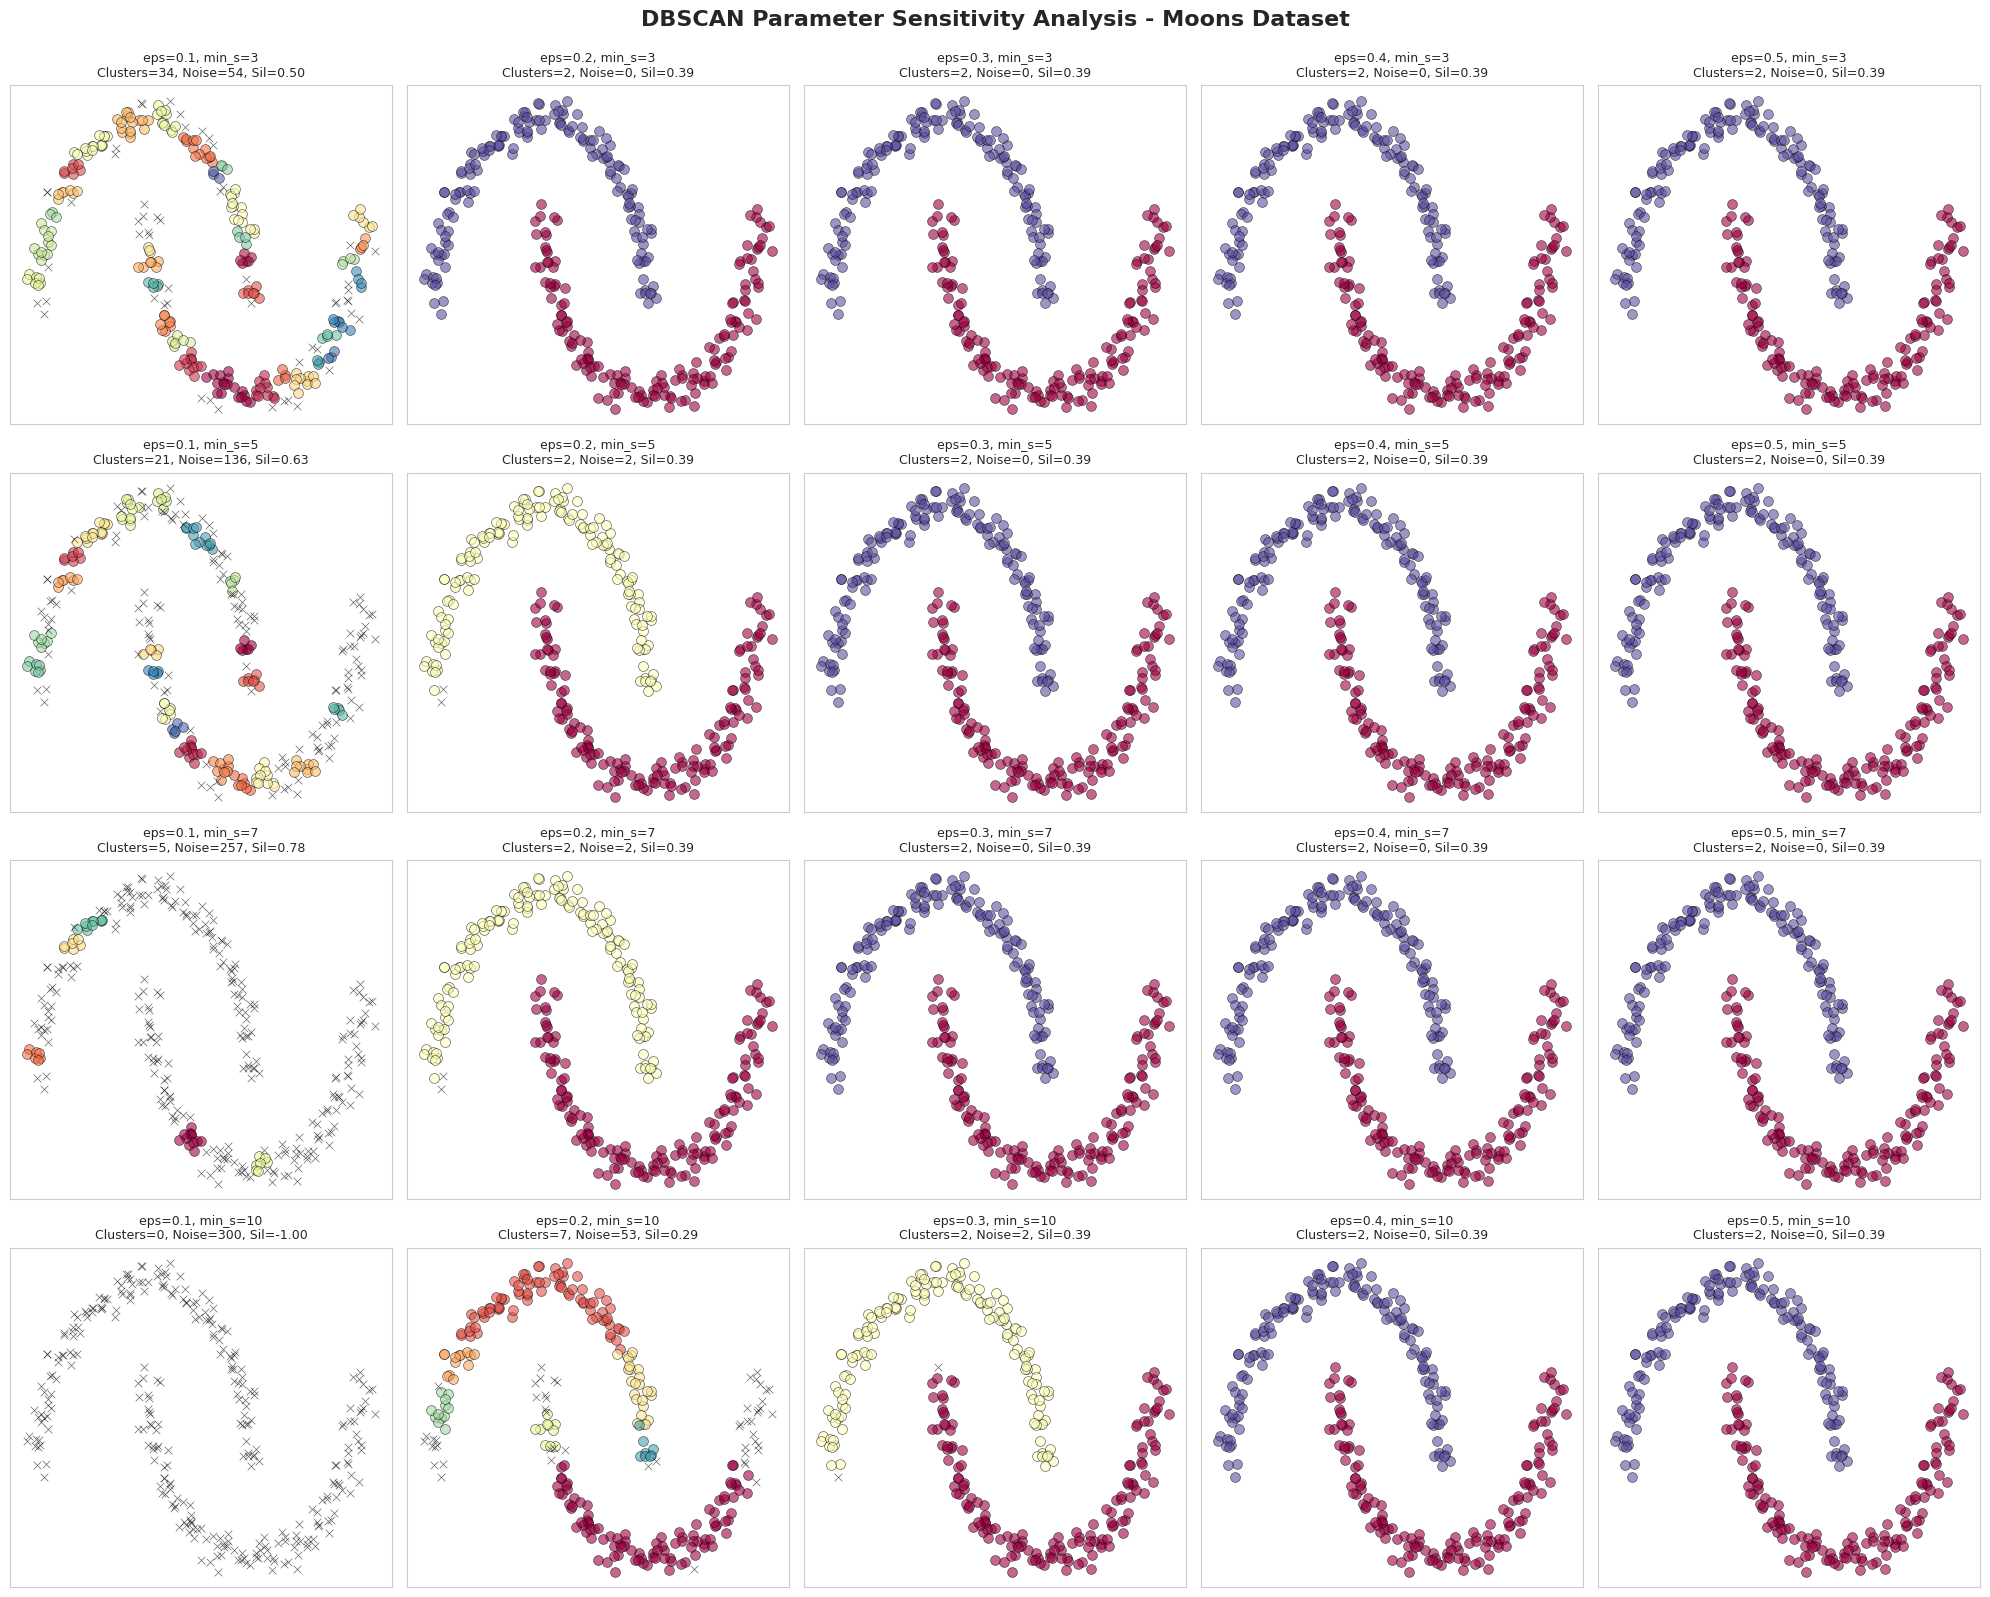

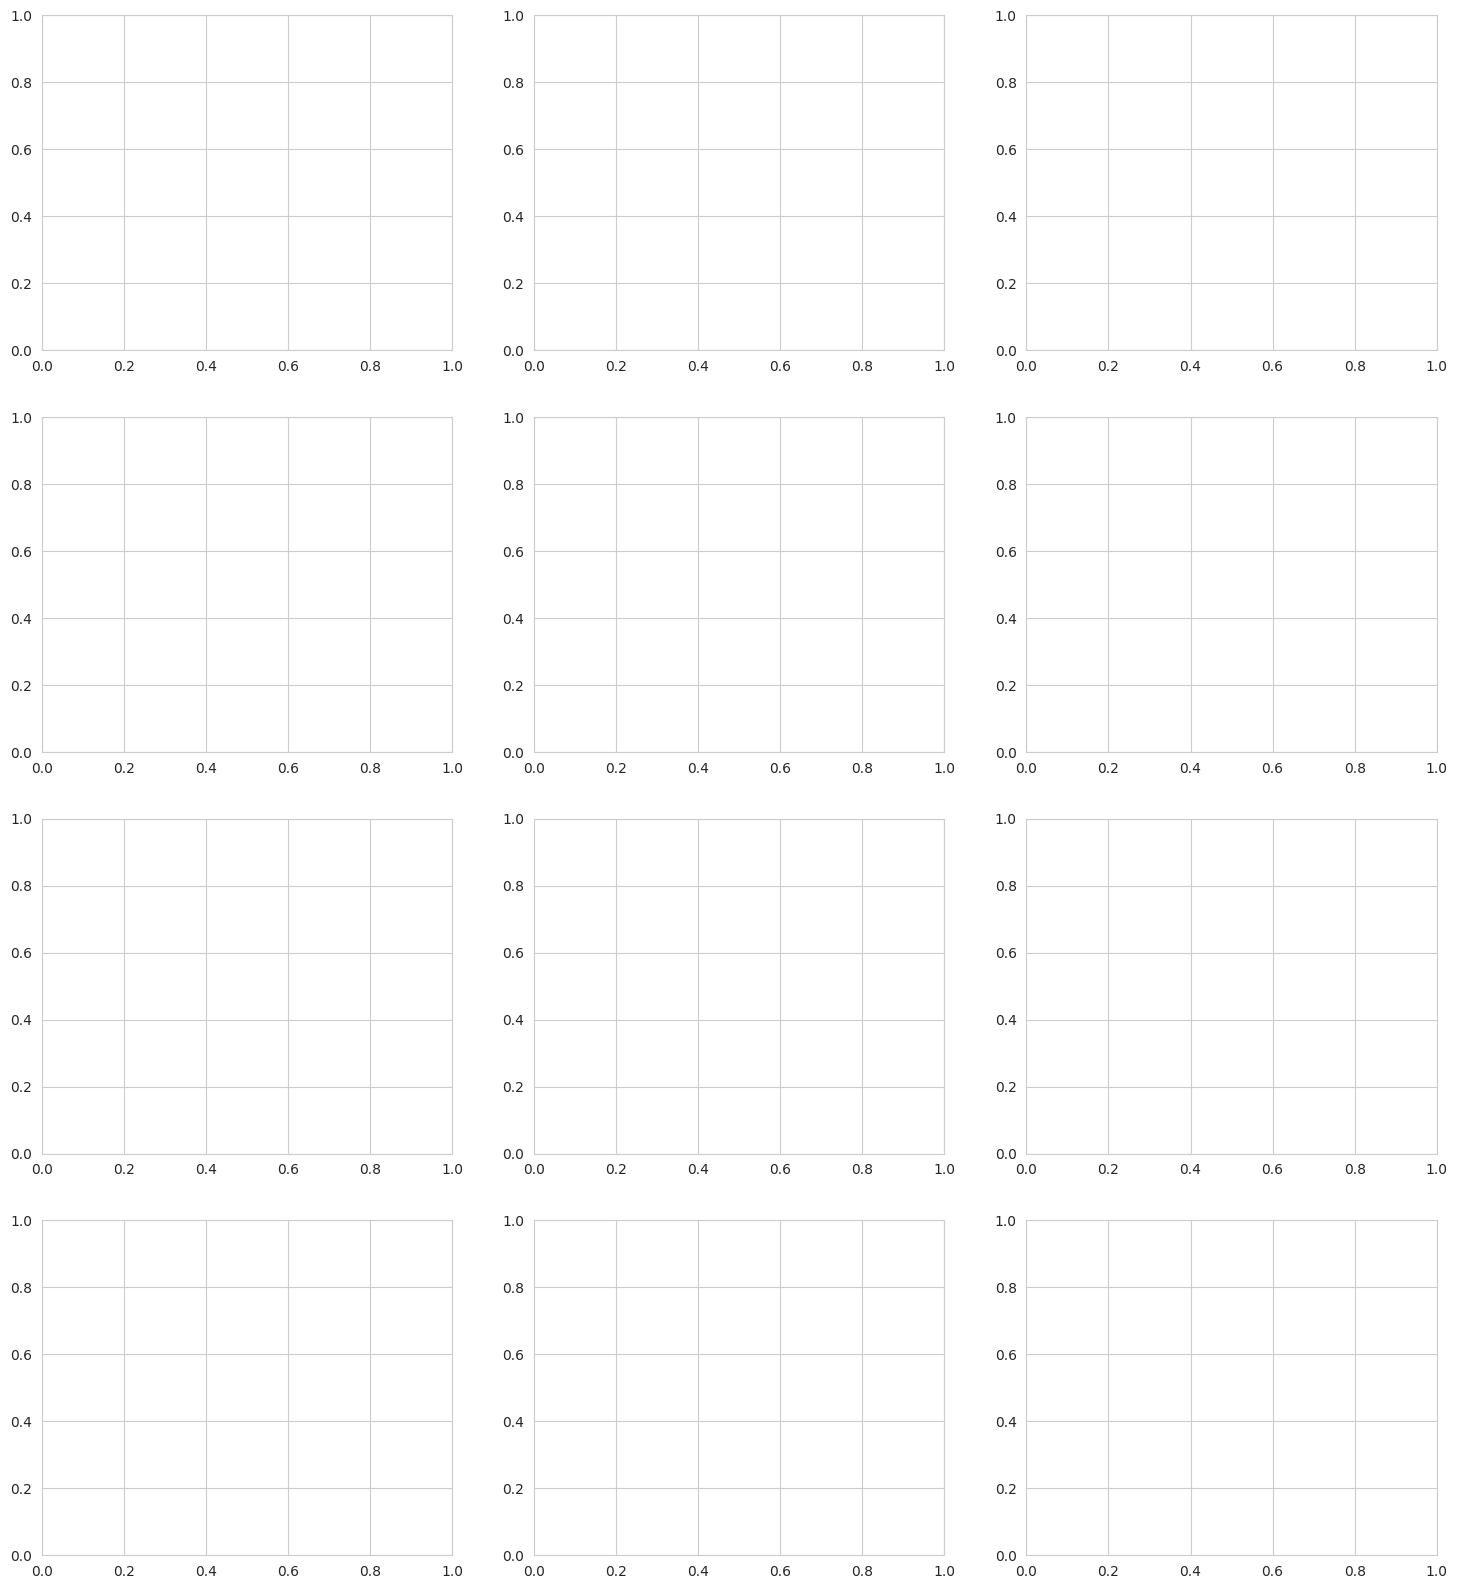

In [10]:
# ================================================================================
# STEP 4: DBSCAN PARAMETER SENSITIVITY ANALYSIS
# ================================================================================
print("\n" + "="*90)
print("STEP 4: PARAMETER SENSITIVITY ANALYSIS")
print("="*90)

# Use Moons dataset for detailed analysis
X_test = X_moons.copy()
scaler = StandardScaler()
X_test_scaled = scaler.fit_transform(X_test)

# Test different eps and min_samples combinations
eps_values = [0.1, 0.2, 0.3, 0.4, 0.5]
min_samples_values = [3, 5, 7, 10]

print(f"\nTesting {len(eps_values)} eps values × {len(min_samples_values)} min_samples values")
print(f"Total combinations: {len(eps_values) * len(min_samples_values)}")

fig, axes = plt.subplots(len(min_samples_values), len(eps_values),
                        figsize=(20, 16))

results_grid = []

for i, min_samp in enumerate(min_samples_values):
    for j, eps in enumerate(eps_values):
        # Run DBSCAN
        dbscan = DBSCAN(eps=eps, min_samples=min_samp)
        labels = dbscan.fit_predict(X_test_scaled)

        # Count clusters and noise
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)

        # Calculate silhouette (only if we have clusters)
        if n_clusters > 0 and n_clusters < len(X_test) - 1:
            # Remove noise points for silhouette calculation
            mask = labels != -1
            if sum(mask) > 0 and len(set(labels[mask])) > 1:
                sil_score = silhouette_score(X_test_scaled[mask], labels[mask])
            else:
                sil_score = -1
        else:
            sil_score = -1

        results_grid.append({
            'eps': eps,
            'min_samples': min_samp,
            'n_clusters': n_clusters,
            'n_noise': n_noise,
            'silhouette': sil_score
        })

        # Plot
        ax = axes[i, j]

        # Separate noise and clusters
        unique_labels = set(labels)
        colors = plt.cm.Spectral(np.linspace(0, 1, len(unique_labels)))

        for k, col in zip(unique_labels, colors):
            if k == -1:
                # Noise: black 'x' markers
                col = [0, 0, 0, 1]
                marker = 'x'
                size = 30
            else:
                marker = 'o'
                size = 50

            class_member_mask = (labels == k)
            xy = X_test_scaled[class_member_mask]
            ax.scatter(xy[:, 0], xy[:, 1], c=[col], marker=marker,
                      s=size, alpha=0.6, edgecolors='black', linewidth=0.5)

        ax.set_title(f'eps={eps}, min_s={min_samp}\n'
                    f'Clusters={n_clusters}, Noise={n_noise}, Sil={sil_score:.2f}',
                    fontsize=9)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.grid(True, alpha=0.3)

plt.suptitle('DBSCAN Parameter Sensitivity Analysis - Moons Dataset',
            fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()

print("\nParameter sensitivity analysis saved!")

# Create summary table
results_df = pd.DataFrame(results_grid)
print(f"\nBest Parameters by Silhouette Score:")
best_params = results_df.loc[results_df['silhouette'].idxmax()]
print(f"  eps: {best_params['eps']}")
print(f"  min_samples: {best_params['min_samples']}")
print(f"  Clusters: {best_params['n_clusters']}")
print(f"  Noise points: {best_params['n_noise']}")
print(f"  Silhouette: {best_params['silhouette']:.4f}")

# ================================================================================
# STEP 5: DBSCAN vs K-MEANS COMPARISON
# ================================================================================
print("\n" + "="*90)
print("STEP 5: DBSCAN vs K-MEANS COMPARISON")
print("="*90)

comparison_text = """
WHY K-MEANS FAILS ON NON-SPHERICAL CLUSTERS:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
K-Means assumptions:
1. Clusters are spherical (round)
2. Clusters have similar sizes
3. Clusters have similar densities
4. No outliers

These assumptions break for:
- Crescent/moon shapes
- Concentric circles
- Elongated clusters
- Data with noise
"""

print(comparison_text)

fig, axes = plt.subplots(4, 3, figsize=(18, 20))

for idx, (X, y_true, name) in enumerate(datasets):
    # Standardize
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Determine optimal k for K-Means
    true_k = len(set(y_true)) - (1 if -1 in y_true else 0)

    # K-Means clustering
    kmeans = KMeans(n_clusters=true_k, random_state=42, n_init=10)
    kmeans_labels = kmeans.fit_predict(X_scaled)

    # DBSCAN clustering (use optimal eps from earlier)
    if idx < len(optimal_eps_values):
        optimal_eps = optimal_eps_values[idx]
    else:
        optimal_eps = 0.3

    dbscan = DBSCAN(eps=optimal_eps, min_samples=4)
    dbscan_labels = dbscan.fit_predict(X_scaled)

    # Count DBSCAN results
    n_clusters_dbscan = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
    n_noise = list(dbscan_labels).count(-1)

    # Calculate metrics for K-Means
    kmeans_sil = silhouette_score(X_scaled, kmeans_labels)
    kmeans_dbi = davies_bouldin_score(X_scaled, kmeans_labels)
    kmeans_ari = adjusted_rand_score(y_true, kmeans_labels)

    # Calculate metrics for DBSCAN (excluding noise)
    mask = dbscan_labels != -1
    if sum(mask) > 0 and len(set(dbscan_labels[mask])) > 1:
        dbscan_sil = silhouette_score(X_scaled[mask], dbscan_labels[mask])
        dbscan_dbi = davies_bouldin_score(X_scaled[mask], dbscan_labels[mask])
        dbscan_ari = adjusted_rand_score(y_true[mask], dbscan_labels[mask])
    else:
        dbscan_sil = -1
        dbscan_dbi = 999
        dbscan_ari = -1

    # Plot True Labels
    ax = axes[idx, 0]
    scatter = ax.scatter(X[:, 0], X[:, 1], c=y_true, cmap='viridis',
                        s=50, alpha=0.6, edgecolors='black', linewidth=0.5)
    ax.set_title(f'{name}\nTrue Labels', fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3)

    # Plot K-Means
    ax = axes[idx, 1]
    scatter = ax.scatter(X[:, 0], X[:, 1], c=kmeans_labels, cmap='viridis',
                        s=50, alpha=0.6, edgecolors='black', linewidth=0.5)
    ax.scatter(scaler.inverse_transform(kmeans.cluster_centers_)[:, 0],
              scaler.inverse_transform(kmeans.cluster_centers_)[:, 1],
              c='red', s=200, alpha=0.8, marker='X', edgecolors='black', linewidth=2)
    ax.set_title(f'K-Means (k={true_k})\n'
                f'Sil={kmeans_sil:.3f}, ARI={kmeans_ari:.3f}',
                fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3)

    # Plot DBSCAN
    ax = axes[idx, 2]

    # Plot clusters
    unique_labels = set(dbscan_labels)
    colors = plt.cm.Spectral(np.linspace(0, 1, len(unique_labels)))

    for k, col in zip(unique_labels, colors):
        if k == -1:
            col = [0, 0, 0, 1]  # Black for noise
            marker = 'x'
            size = 40
            alpha = 0.4
        else:
            marker = 'o'
            size = 50
            alpha = 0.6

        class_member_mask = (dbscan_labels == k)
        xy = X[class_member_mask]
        ax.scatter(xy[:, 0], xy[:, 1], c=[col], marker=marker,
                  s=size, alpha=alpha, edgecolors='black', linewidth=0.5)

    ax.set_title(f'DBSCAN (eps={optimal_eps:.2f})\n'
                f'Clusters={n_clusters_dbscan}, Noise={n_noise}, '
                f'Sil={dbscan_sil:.3f}, ARI={dbscan_ari:.3f}',
                fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3)

    print(f"\n{name}:")
    print(f"  K-Means: Silhouette={kmeans_sil:.4f}, DBI={kmeans_dbi:.4f}, ARI={kmeans_ari:.4f}")
    print(f"  DBSCAN:  Silhouette={dbscan_sil:.4f}, DBI={dbscan_dbi:.4f}, ARI={dbscan_ari:.4f}")
    print(f"  DBSCAN found {n_clusters_dbscan} clusters and {n_noise} noise points")

plt.tight_layout()
plt.savefig('/content/')

# ================================================================================
# STEP 6: DETAILED DBSCAN ANALYSIS - CORE, BORDER, NOISE
# ================================================================================
print("\n" + "="*90)
print("STEP 6: IDENTIFYING CORE, BORDER, AND NOISE POINTS")
print("="*90)

# Use Moons dataset
X_analysis = X_moons.copy()
scaler = StandardScaler()
X_analysis_scaled = scaler.fit_transform(X_analysis)

# Run DBSCAN with optimal parameters
dbscan_analysis = DBSCAN(eps=0.3, min_samples=5)
labels_analysis = dbscan_analysis.fit_predict(X_analysis_scaled)

# Identify core samples
core_samples_mask = np.zeros_like(labels_analysis, dtype=bool)
core_samples_mask[dbscan_analysis.core_sample_indices_] = True

# Classify each point
point_types = []
for i in range(len(X_analysis)):
    if labels_analysis[i] == -1:
        point_types.append('Noise')
    elif core_samples_mask[i]:
        point_types.append('Core')
    else:
        point_types.append('Border')

point_types = np.array(point_types)

# Count each type
n_core = sum(point_types == 'Core')
n_border = sum(point_types == 'Border')
n_noise = sum(point_types == 'Noise')

print(f"\nPoint Classification:")
print(f"  Core points:   {n_core:3d} ({n_core/len(X_analysis)*100:.1f}%)")
print(f"  Border points: {n_border:3d} ({n_border/len(X_analysis)*100:.1f}%)")
print(f"  Noise points:  {n_noise:3d} ({n_noise/len(X_analysis)*100:.1f}%)")

# Visualize point types
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: By cluster
ax = axes[0]
unique_labels = set(labels_analysis)
colors = plt.cm.Spectral(np.linspace(0, 1, len(unique_labels)))

for k, col in zip(unique_labels, colors):
    if k == -1:
        col = [0, 0, 0, 1]

    class_member_mask = (labels_analysis == k)

    # Core points
    xy = X_analysis[class_member_mask & core_samples_mask]
    ax.scatter(xy[:, 0], xy[:, 1], c=[col], marker='o', s=100,
              alpha=0.8, edgecolors='black', linewidth=1.5, label=f'Cluster {k}' if k != -1 else 'Noise')

    # Border points
    xy = X_analysis[class_member_mask & ~core_samples_mask]
    ax.scatter(xy[:, 0], xy[:, 1], c=[col], marker='o', s=50,
              alpha=0.5, edgecolors='black', linewidth=0.5)

ax.set_title('DBSCAN Clusters\n(Large circles = Core, Small circles = Border, Black = Noise)',
            fontsize=13, fontweight='bold')
ax.set_xlabel('Feature 1', fontsize=11)
ax.set_ylabel('Feature 2', fontsize=11)
ax.grid(True, alpha=0.3)

# Plot 2: By point type
ax = axes[1]

colors_types = {'Core': 'blue', 'Border': 'orange', 'Noise': 'red'}
markers_types = {'Core': 'o', 'Border': '^', 'Noise': 'x'}
sizes_types = {'Core': 100, 'Border': 80, 'Noise': 60}

for ptype in ['Core', 'Border', 'Noise']:
    mask = point_types == ptype
    ax.scatter(X_analysis[mask, 0], X_analysis[mask, 1],
              c=colors_types[ptype], marker=markers_types[ptype],
              s=sizes_types[ptype], alpha=0.7, edgecolors='black',
              linewidth=1, label=f'{ptype} ({sum(mask)})')

ax.set_title('Point Type Classification', fontsize=13, fontweight='bold')
ax.set_xlabel('Feature 1', fontsize=11)
ax.set_ylabel('Feature 2', fontsize=11)
ax.legend(loc='best', fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/home/claude/dbscan_point_types.png', dpi=300, bbox_inches='tight')
print("\nPoint type visualization saved!")